# Missouri Voter Resource Allocation — Geo Pipeline

Builds precinct-level feature datasets for 2016, 2020, and 2024 Missouri elections.

**Pipeline stages:**
- Stage 0 — Configuration & Imports
- Stage 1 — Load VEST Precinct Shapefiles
- Stage 2 — Load Census Block Data
- Stage 3 — Inspect VEST Column Structure
- Stage 4 — Create Precinct Identifiers (composite_prec_id)
- Stage 5 — Load ACS Staging Data
- Stage 6 — Build Full Precinct Features
- Stage 7 — County Aggregation
- Stage 8 — Save Outputs
- Map Review

## Stage 0 — Configuration & Imports

In [ ]:
import sys
import re
import logging
import pandas as pd
import geopandas as gpd
from pathlib import Path

logging.basicConfig(level=logging.INFO, format='%(levelname)s: %(message)s')

# Assumes notebook lives in <project_root>/notebooks/
PROJECT_ROOT = Path('..').resolve()
DATA_ROOT    = PROJECT_ROOT / 'data'
GEO_RAW      = DATA_ROOT / 'geo' / 'raw'
PROCESSED    = DATA_ROOT / 'processed'
GEO_OUT      = DATA_ROOT / 'geo' / 'output'
GEO_OUT.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT / 'src'))

from geo_loader          import GeoLoader
from census_block_loader import CensusBlockLoader
from precinct_builder    import (
    build_precinct_features,
    aggregate_to_county,
    COUNTY_FIPS_CANDIDATES,
)

# Get a free Census API key at: https://api.census.gov/data/key_signup.html
# Only needed on first run; data is cached locally after that.
CENSUS_API_KEY = 'YOUR_CENSUS_API_KEY_HERE'

ELECTION_YEARS = [2016, 2020, 2024]

print('Configuration complete.')
print(f'  Project root : {PROJECT_ROOT}')
print(f'  GEO raw dir  : {GEO_RAW}')
print(f'  Processed dir: {PROCESSED}')
print(f'  GEO output   : {GEO_OUT}')

## Stage 1 — Load VEST Precinct Shapefiles

In [ ]:
geo_loader = GeoLoader(geo_raw_dir=str(GEO_RAW))
vest = {}

for year in ELECTION_YEARS:
    print(f'\nLoading {year} VEST shapefile...')
    vest[year] = geo_loader.get_precinct_shapefile(year)
    print(f'  {year}: {len(vest[year]):,} rows | CRS = {vest[year].crs}')
    print(f'  Columns: {vest[year].columns.tolist()}')

print('\nAll VEST shapefiles loaded.')

## Stage 2 — Load Census Block Data

Downloads Missouri 2020 Census block geometries and PL 94-171 population on
first run. Both are cached locally after that.

In [ ]:
print('Loading census block data...')
block_loader = CensusBlockLoader(
    geo_raw_dir=str(GEO_RAW),
    census_api_key=CENSUS_API_KEY,
)
blocks_gdf = block_loader.get_blocks_with_population()

print(f'\nBlocks loaded : {len(blocks_gdf):,} rows')
print(f'Columns       : {blocks_gdf.columns.tolist()}')
print(f'CRS           : {blocks_gdf.crs}')
print(f'Total pop     : {blocks_gdf["total_population"].sum():,.0f}')
print(f'Total VAP     : {blocks_gdf["vap_total"].sum():,.0f}')

## Stage 3 — Inspect VEST Column Structure

Confirms presidential vote columns exist for each year and identifies the
county FIPS column name (varies across VEST vintages).

In [ ]:
print('=== Presidential vote column check ===')

for year in ELECTION_YEARS:
    suffix   = str(year)[2:]
    pre_cols = [c for c in vest[year].columns if re.match(rf'^G{suffix}PRE[A-Z]+$', c)]
    county_col = next(
        (c for c in COUNTY_FIPS_CANDIDATES if c in vest[year].columns), 'NOT FOUND'
    )
    text_cols = [
        c for c in vest[year].select_dtypes(include='object').columns
        if c != 'geometry'
    ]
    print(f'\n{year}:')
    print(f'  County column          : {county_col}')
    print(f'  Presidential cols ({len(pre_cols):2d}) : {pre_cols}')
    print(f'  Text columns           : {text_cols}')

## Stage 4 — Create Precinct Identifiers

Builds `composite_prec_id` = `COUNTYFP_<precinct_name>` using year-specific
column names (2016/2020 use `NAME`; 2024 uses `Precinct`).

Split precincts (same name, multiple polygon rows) are dissolved: geometries
unioned, vote columns summed. Affects 2016 (1 pair) and 2024 (~257).

In [ ]:
PRECINCT_NAME_COL = {
    2016: 'NAME',
    2020: 'NAME',
    2024: 'Precinct',
}

for year in ELECTION_YEARS:
    vest[year] = vest[year].copy()
    vest[year]['composite_prec_id'] = (
        vest[year]['COUNTYFP'].str.zfill(3)
        + '_'
        + vest[year][PRECINCT_NAME_COL[year]].astype(str)
    )
    print(f'{year}: composite_prec_id created ({len(vest[year]):,} rows before dissolve)')


def dissolve_split_precincts(vest_gdf, precinct_id_col):
    vote_cols  = [c for c in vest_gdf.columns if re.match(r'^G\d{2}', c)]
    other_cols = [
        c for c in vest_gdf.columns
        if c not in vote_cols + ['geometry', precinct_id_col]
    ]
    agg = {col: 'sum'   for col in vote_cols}
    agg.update({col: 'first' for col in other_cols})
    return vest_gdf.dissolve(by=precinct_id_col, aggfunc=agg).reset_index()


for year in [2016, 2024]:
    n_before = len(vest[year])
    vest[year] = dissolve_split_precincts(vest[year], 'composite_prec_id')
    print(f'{year}: {n_before:,} -> {len(vest[year]):,} rows after dissolving split precincts')


PRECINCT_ID_COL = 'composite_prec_id'


print('\n=== Precinct ID uniqueness check ===')
for year in ELECTION_YEARS:
    n = len(vest[year])
    u = vest[year][PRECINCT_ID_COL].nunique()
    status = 'OK' if n == u else f'WARNING: {n - u} duplicates remain!'
    print(f'  {year}: {n:,} rows, {u:,} unique  [{status}]')

## Stage 5 — Load ACS Staging Data

Loads county-level ACS staging CSVs. Downscaled to precinct level via
population-weighted apportionment inside `build_precinct_features`.

In [ ]:
acs_files = {
    'income'    : 'stg_census_income.csv',
    'education' : 'stg_census_education.csv',
    'race'      : 'stg_census_race.csv',
    'commute'   : 'stg_census_commute.csv',
    'sex_age'   : 'stg_census_sex_age.csv',
}

acs_staging_dfs = {}

for category, filename in acs_files.items():
    path = PROCESSED / filename
    df   = pd.read_csv(path, dtype={'county_fips': str})
    df   = df[df['census_year'].isin(ELECTION_YEARS)].copy()
    acs_staging_dfs[category] = df
    print(f'  {category:10s}: {len(df):,} rows | columns: {df.columns.tolist()}')

print(f'\n{len(acs_staging_dfs)} ACS staging datasets loaded.')

## Stage 6 — Build Full Precinct Features

`build_precinct_features` orchestrates CRS alignment, area-weighted block
apportionment, vote extraction, turnout calculation, and ACS downscaling.

The `gpd.overlay` intersection may take **1-3 minutes per year**.

In [ ]:
precinct_features = {}

for year in ELECTION_YEARS:
    precinct_features[year] = build_precinct_features(
        vest_gdf        = vest[year],
        blocks_gdf      = blocks_gdf,
        acs_staging_dfs = acs_staging_dfs,
        year            = year,
        precinct_id_col = PRECINCT_ID_COL,
    )

print('\n=== Precinct feature summary ===')
for year in ELECTION_YEARS:
    gdf = precinct_features[year]
    print(f'  {year}: {len(gdf):,} precincts | {len(gdf.columns)} columns')
    if 'turnout_pct' in gdf.columns:
        med = gdf['turnout_pct'].dropna().median()
        print(f'    Median turnout: {med:.1f}%')
    print(f'    Columns: {gdf.columns.tolist()}')

### Turnout Cap

A small number of precincts receive apportioned VAP slightly below their
actual vote count due to 2020 block boundaries not perfectly matching
older precinct shapes. Cap at 100% before modeling.

In [ ]:
for year in ELECTION_YEARS:
    if 'turnout_pct' in precinct_features[year].columns:
        n_capped = (precinct_features[year]['turnout_pct'] > 100).sum()
        precinct_features[year]['turnout_pct'] = (
            precinct_features[year]['turnout_pct'].clip(upper=100)
        )
        if n_capped > 0:
            print(f'{year}: {n_capped} precincts capped at 100% turnout')

### Post-Stage-6 Data Quality Check

Validates vote columns, party splits, turnout distribution, and VAP
apportionment coverage before proceeding to county aggregation.

In [ ]:
print('=' * 60)
print('DATA QUALITY REPORT — post Stage 6')
print('=' * 60)

for year in ELECTION_YEARS:
    gdf = precinct_features[year]
    print(f'\n--- {year} ({len(gdf):,} precincts) ---')

    # 1. Vote column classification sanity check
    suffix = str(year)[2:]
    pre_cols = [c for c in gdf.columns if re.match(rf'^G{suffix}PRE[A-Z]+$', c)]
    rep_cols   = [c for c in pre_cols if len(c) > 6 and c[6] == 'R']
    dem_cols   = [c for c in pre_cols if len(c) > 6 and c[6] == 'D']
    other_cols = [c for c in pre_cols if len(c) > 6 and c[6] not in ('R','D')]
    print(f'  Vote cols  — R: {rep_cols}  |  D: {dem_cols}  |  other: {other_cols}')

    # 2. Votes sanity
    for col in ['rep_votes', 'dem_votes', 'total_votes']:
        if col in gdf.columns:
            print(f'  {col:15s}: sum={gdf[col].sum():,.0f}  zeros={( gdf[col]==0).sum()}')

    # 3. Party split
    if {'rep_pct', 'dem_pct'}.issubset(gdf.columns):
        print(f'  rep_pct  range : {gdf["rep_pct"].min():.1f}% – {gdf["rep_pct"].max():.1f}%  '
              f'median={gdf["rep_pct"].median():.1f}%')
        print(f'  dem_pct  range : {gdf["dem_pct"].min():.1f}% – {gdf["dem_pct"].max():.1f}%  '
              f'median={gdf["dem_pct"].median():.1f}%')

    # 4. VAP apportionment coverage
    if 'apportioned_vap' in gdf.columns:
        vap = gdf['apportioned_vap']
        block_vap = blocks_gdf['vap_total'].sum()
        coverage  = vap.sum() / block_vap * 100 if block_vap > 0 else float('nan')
        print(f'  apportioned_vap: sum={vap.sum():,.0f}  '
              f'(Census block VAP={block_vap:,.0f}  coverage={coverage:.1f}%)')
        print(f'  apportioned_vap: zeros={( vap==0).sum()}  '
              f'NaN={(vap.isna()).sum()}  min={vap.min():.1f}  mean={vap.mean():.1f}')

    # 5. Turnout distribution
    if 'turnout_pct' in gdf.columns:
        t = gdf['turnout_pct'].dropna()
        print(f'  turnout_pct    : median={t.median():.1f}%  '
              f'p10={t.quantile(0.1):.1f}%  p90={t.quantile(0.9):.1f}%  '
              f'max={t.max():.1f}%  >100pct={(t>100).sum()}')

print('\n' + '=' * 60)


## Stage 7 — County Aggregation

Rolls precinct data to county level: votes and population summed;
rates population-weighted averaged; geometries unioned.

In [ ]:
county_col = next(
    c for c in COUNTY_FIPS_CANDIDATES
    if c in precinct_features[ELECTION_YEARS[0]].columns
)
print(f"County column detected: '{county_col}'")

county_features = {}

for year in ELECTION_YEARS:
    county_features[year] = aggregate_to_county(
        precinct_features[year],
        precinct_id_col = PRECINCT_ID_COL,
        county_col      = county_col,
    )
    print(f'  {year}: {len(county_features[year])} counties')

print('\nCounty aggregation complete.')

## Stage 8 — Save Outputs

Tabular CSVs to `data/processed/` for modeling; GeoPackages to
`data/geo/output/` for GIS visualization.

In [ ]:
import warnings

all_precinct = pd.concat(
    [precinct_features[y].drop(columns='geometry', errors='ignore') for y in ELECTION_YEARS],
    ignore_index=True,
)
all_county = pd.concat(
    [county_features[y].drop(columns='geometry', errors='ignore') for y in ELECTION_YEARS],
    ignore_index=True,
)

precinct_csv = PROCESSED / 'precinct_features_all_years.csv'
county_csv   = PROCESSED / 'county_features_all_years.csv'
all_precinct.to_csv(precinct_csv, index=False)
all_county.to_csv(county_csv,     index=False)
print(f'Saved: {precinct_csv}  ({len(all_precinct):,} rows)')
print(f'Saved: {county_csv}  ({len(all_county):,} rows)')

for year in ELECTION_YEARS:
    prec_gpkg = GEO_OUT / f'precinct_features_{year}.gpkg'
    cnty_gpkg = GEO_OUT / f'county_features_{year}.gpkg'
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        precinct_features[year].to_file(prec_gpkg, driver='GPKG')
        county_features[year].to_file(cnty_gpkg,   driver='GPKG')
    print(f'Saved: {prec_gpkg}')
    print(f'Saved: {cnty_gpkg}')

print('\nAll outputs saved.')

## Diagnostics (optional)

In [ ]:
print('=== Precinct turnout by year ===')
for year in ELECTION_YEARS:
    gdf = precinct_features[year]
    if 'turnout_pct' in gdf.columns:
        t = gdf['turnout_pct'].dropna()
        print(f'  {year}: n={len(t):,}  median={t.median():.1f}%  '
              f'p10={t.quantile(0.10):.1f}%  p90={t.quantile(0.90):.1f}%  '
              f'>100pct: {(t > 100).sum()}')

In [ ]:
print('=== Apportioned population vs Census block total ===')
block_total = blocks_gdf['total_population'].sum()
print(f'  Census blocks total: {block_total:,.0f}')
for year in ELECTION_YEARS:
    if 'apportioned_population' in precinct_features[year].columns:
        apportioned = precinct_features[year]['apportioned_population'].sum()
        coverage    = apportioned / block_total * 100
        print(f'  {year}: {apportioned:,.0f} apportioned  ({coverage:.1f}% coverage)')

## Map Review

Each section generates a static PNG saved to `data/geo/output/` and an
interactive Folium choropleth displayed inline.

Change `REVIEW_YEAR` in the setup cell to switch all three maps to a
different election year.

In [ ]:
import folium
import matplotlib.pyplot as plt

MO_CENTER   = [38.5, -92.5]
REVIEW_YEAR = 2020   # change to 2016 or 2024

# Reproject to WGS84 for Folium
# make_valid() fixes any degenerate geometries produced by the dissolve step
# (e.g. unclosed LinearRings) that would otherwise cause a GEOSException in to_crs()
gdf_review = precinct_features[REVIEW_YEAR].copy()
gdf_review['geometry'] = gdf_review.geometry.make_valid()
gdf_review = gdf_review.to_crs('EPSG:4326')

# Round display columns so tooltips stay readable
for col in ['turnout_pct', 'rep_pct', 'dem_pct']:
    if col in gdf_review.columns:
        gdf_review[col] = gdf_review[col].round(1)
if 'apportioned_population' in gdf_review.columns:
    gdf_review['apportioned_population'] = (
        gdf_review['apportioned_population'].round(0).astype('Int64')
    )

# Human-readable precinct label (strip the leading county FIPS prefix)
gdf_review['precinct_label'] = (
    gdf_review[PRECINCT_ID_COL].str.split('_', n=1).str[1]
)

print(f'Prepared {len(gdf_review):,} precincts for {REVIEW_YEAR}.')
print(f'Turnout range : {gdf_review["turnout_pct"].min():.1f}% - {gdf_review["turnout_pct"].max():.1f}%')
print(f'Rep pct range : {gdf_review["rep_pct"].min():.1f}% - {gdf_review["rep_pct"].max():.1f}%')

### Map 1 — Voter Turnout (%)

In [ ]:
# Static PNG
fig, ax = plt.subplots(figsize=(16, 11))
gdf_review.plot(
    column       = 'turnout_pct',
    ax           = ax,
    cmap         = 'YlOrRd',
    legend       = True,
    legend_kwds  = {'label': 'Turnout (%)', 'orientation': 'horizontal',
                    'shrink': 0.5, 'pad': 0.02},
    missing_kwds = {'color': 'lightgray', 'label': 'No data'},
    linewidth    = 0.2,
    edgecolor    = '#555',
)
ax.set_title(f'Voter Turnout (%) - Missouri Precincts {REVIEW_YEAR}', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
png_path = GEO_OUT / f'map_turnout_{REVIEW_YEAR}.png'
plt.savefig(png_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {png_path}')

# Interactive Folium
turnout_cols = [PRECINCT_ID_COL, 'precinct_label', 'turnout_pct',
                'total_votes', 'apportioned_vap', 'geometry']
turnout_cols = [c for c in turnout_cols if c in gdf_review.columns]
geojson_turnout = gdf_review[turnout_cols].to_json()

m_turnout = folium.Map(location=MO_CENTER, zoom_start=7, tiles='CartoDB positron')

folium.Choropleth(
    geo_data       = geojson_turnout,
    data           = gdf_review[[PRECINCT_ID_COL, 'turnout_pct']].dropna(),
    columns        = [PRECINCT_ID_COL, 'turnout_pct'],
    key_on         = f'feature.properties.{PRECINCT_ID_COL}',
    fill_color     = 'YlOrRd',
    fill_opacity   = 0.7,
    line_opacity   = 0.15,
    line_weight    = 0.4,
    legend_name    = f'Voter Turnout (%) - {REVIEW_YEAR}',
    nan_fill_color = 'lightgray',
).add_to(m_turnout)

folium.GeoJson(
    geojson_turnout,
    style_function = lambda x: {'fillOpacity': 0, 'weight': 0.3, 'color': '#555'},
    tooltip = folium.GeoJsonTooltip(
        fields   = [f for f in ['precinct_label', PRECINCT_ID_COL,
                                 'turnout_pct', 'total_votes', 'apportioned_vap']
                    if f in turnout_cols],
        aliases  = [a for a, c in [('Precinct', 'precinct_label'),
                                    ('ID', PRECINCT_ID_COL),
                                    ('Turnout %', 'turnout_pct'),
                                    ('Total Votes', 'total_votes'),
                                    ('Apportioned VAP', 'apportioned_vap')]
                    if c in turnout_cols],
        localize = True,
    ),
).add_to(m_turnout)

m_turnout

### Map 2 — Republican Vote Share (%)

In [ ]:
# Static PNG
fig, ax = plt.subplots(figsize=(16, 11))
gdf_review.plot(
    column       = 'rep_pct',
    ax           = ax,
    cmap         = 'RdBu_r',
    vmin         = 0,
    vmax         = 100,
    legend       = True,
    legend_kwds  = {'label': 'Republican Vote Share (%)', 'orientation': 'horizontal',
                    'shrink': 0.5, 'pad': 0.02},
    missing_kwds = {'color': 'lightgray', 'label': 'No data'},
    linewidth    = 0.2,
    edgecolor    = '#555',
)
ax.set_title(f'Republican Vote Share (%) - Missouri Precincts {REVIEW_YEAR}', fontsize=14)
ax.set_axis_off()
plt.tight_layout()
png_path = GEO_OUT / f'map_party_{REVIEW_YEAR}.png'
plt.savefig(png_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {png_path}')

# Interactive Folium
party_cols = [PRECINCT_ID_COL, 'precinct_label', 'rep_pct',
               'dem_pct', 'total_votes', 'geometry']
party_cols = [c for c in party_cols if c in gdf_review.columns]
geojson_party = gdf_review[party_cols].to_json()

m_party = folium.Map(location=MO_CENTER, zoom_start=7, tiles='CartoDB positron')

folium.Choropleth(
    geo_data       = geojson_party,
    data           = gdf_review[[PRECINCT_ID_COL, 'rep_pct']].dropna(),
    columns        = [PRECINCT_ID_COL, 'rep_pct'],
    key_on         = f'feature.properties.{PRECINCT_ID_COL}',
    fill_color     = 'RdBu_r',
    fill_opacity   = 0.7,
    line_opacity   = 0.15,
    line_weight    = 0.4,
    legend_name    = f'Republican Vote Share (%) - {REVIEW_YEAR}',
    nan_fill_color = 'lightgray',
).add_to(m_party)

folium.GeoJson(
    geojson_party,
    style_function = lambda x: {'fillOpacity': 0, 'weight': 0.3, 'color': '#555'},
    tooltip = folium.GeoJsonTooltip(
        fields   = [f for f in ['precinct_label', PRECINCT_ID_COL,
                                 'rep_pct', 'dem_pct', 'total_votes']
                    if f in party_cols],
        aliases  = [a for a, c in [('Precinct', 'precinct_label'),
                                    ('ID', PRECINCT_ID_COL),
                                    ('Rep %', 'rep_pct'),
                                    ('Dem %', 'dem_pct'),
                                    ('Total Votes', 'total_votes')]
                    if c in party_cols],
        localize = True,
    ),
).add_to(m_party)

m_party

### Map 3 — Apportioned Population

Population stats (n=3,733):
  median : 1,185
  p90    : 3,817
  p99    : 7,099
  max    : 28,771
  zeros  : 147

Top 10 precincts by apportioned population:
                  composite_prec_id                precinct_label  apportioned_population
0                    169_St. Robert                    St. Robert                   28771
1                   207_Dexter/Pyle                   Dexter/Pyle                   12192
2                   169_Waynesville                   Waynesville                   11463
3           101_Warrensburg SE-2/NE           Warrensburg SE-2/NE                   10499
4                    183_Hawk Ridge                    Hawk Ridge                   10349
5  021_Our Lady of Guadalupe Church  Our Lady of Guadalupe Church                    9985
6              077_2nd Campbell A/C              2nd Campbell A/C                    9853
7                   019_1E/1I/6B/6F                   1E/1I/6B/6F                    9792
8                 083_Benson Cent

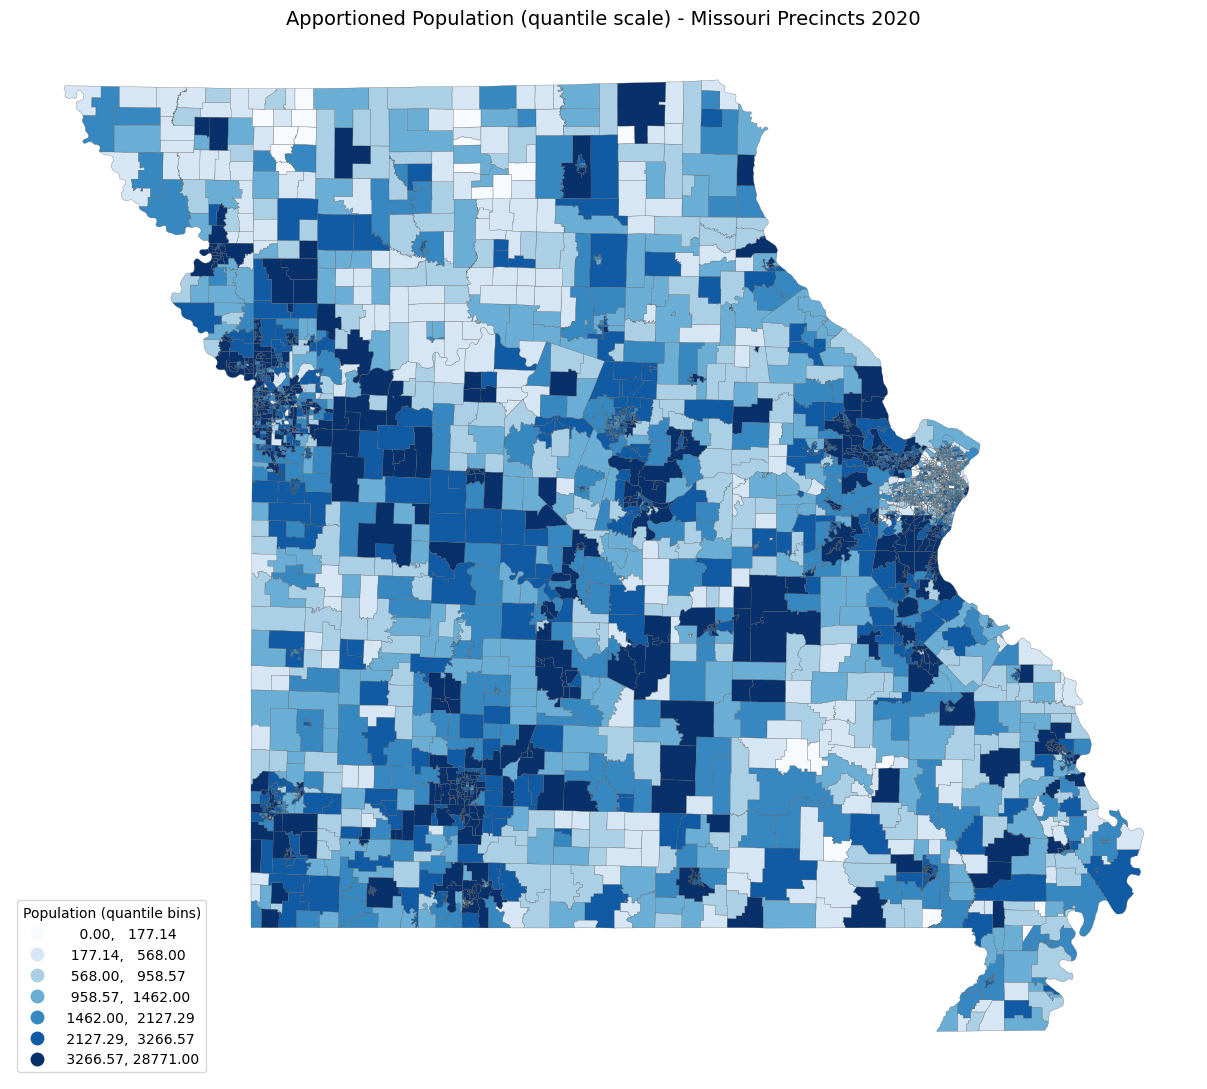

Saved: C:\Users\daves\OneDrive\Documents\School\SP26\AnalyticsApps\final\AnalyticsApps\data\geo\output\map_population_2020.png


In [ ]:
import numpy as np

# --- Population outlier check ---
# Population is naturally skewed (dense urban >> rural), so flag the top
# precincts to confirm they are genuine high-density areas, not data errors.
pop_series = gdf_review['apportioned_population'].dropna()
print(f'Population stats (n={len(pop_series):,}):')
print(f'  median : {pop_series.median():,.0f}')
print(f'  p90    : {pop_series.quantile(0.90):,.0f}')
print(f'  p99    : {pop_series.quantile(0.99):,.0f}')
print(f'  max    : {pop_series.max():,.0f}')
print(f'  zeros  : {(pop_series == 0).sum()}')
print()
print('Top 10 precincts by apportioned population:')
top10 = (
    gdf_review[[PRECINCT_ID_COL, 'precinct_label', 'apportioned_population']]
    .nlargest(10, 'apportioned_population')
    .reset_index(drop=True)
)
print(top10.to_string())

# --- Static PNG (quantile scheme so skew doesn't wash out the map) ---
# 'quantiles' divides precincts into equal-sized color buckets, which shows
# relative population density regardless of the absolute scale.
fig, ax = plt.subplots(figsize=(16, 11))
gdf_review.plot(
    column       = 'apportioned_population',
    ax           = ax,
    cmap         = 'Blues',
    scheme       = 'quantiles',
    k            = 7,
    legend       = True,
    legend_kwds  = {'title': 'Population (quantile bins)', 'frameon': True,
                    'loc': 'lower left'},
    missing_kwds = {'color': 'lightgray', 'label': 'No data'},
    linewidth    = 0.2,
    edgecolor    = '#555',
)
ax.set_title(f'Apportioned Population (quantile scale) - Missouri Precincts {REVIEW_YEAR}',
             fontsize=14)
ax.set_axis_off()
plt.tight_layout()
png_path = GEO_OUT / f'map_population_{REVIEW_YEAR}.png'
plt.savefig(png_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {png_path}')

# --- Interactive Folium ---
pop_cols = [PRECINCT_ID_COL, 'precinct_label', 'apportioned_population',
             'apportioned_vap', 'geometry']
pop_cols = [c for c in pop_cols if c in gdf_review.columns]
geojson_pop = gdf_review[pop_cols].to_json()

m_pop = folium.Map(location=MO_CENTER, zoom_start=7, tiles='CartoDB positron')

folium.Choropleth(
    geo_data       = geojson_pop,
    data           = gdf_review[[PRECINCT_ID_COL, 'apportioned_population']].dropna(),
    columns        = [PRECINCT_ID_COL, 'apportioned_population'],
    key_on         = f'feature.properties.{PRECINCT_ID_COL}',
    fill_color     = 'Blues',
    fill_opacity   = 0.7,
    line_opacity   = 0.15,
    line_weight    = 0.4,
    legend_name    = f'Apportioned Population - {REVIEW_YEAR}',
    nan_fill_color = 'lightgray',
).add_to(m_pop)

folium.GeoJson(
    geojson_pop,
    style_function = lambda x: {'fillOpacity': 0, 'weight': 0.3, 'color': '#555'},
    tooltip = folium.GeoJsonTooltip(
        fields   = [f for f in ['precinct_label', PRECINCT_ID_COL,
                                 'apportioned_population', 'apportioned_vap']
                    if f in pop_cols],
        aliases  = [a for a, c in [('Precinct', 'precinct_label'),
                                    ('ID', PRECINCT_ID_COL),
                                    ('Population', 'apportioned_population'),
                                    ('VAP', 'apportioned_vap')]
                    if c in pop_cols],
        localize = True,
    ),
).add_to(m_pop)

m_pop